In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# CONFIGURATION


class Config:
    """Configuration for data paths and parameters"""

    # Input paths
    RAW_DATA_DIR = Path(r"D:\bhopal-pollutant-prediction\Raw_Data\Pollution_Data")
    WEATHER_FILE = Path(r"D:\bhopal-pollutant-prediction\processed_data\weather_merged_complete.csv")

    # Output paths
    OUTPUT_DIR = Path(r"D:\bhopal-pollutant-prediction\processed_data")
    FINAL_DATASET = OUTPUT_DIR / "bhopal_aqi_weather_final.csv"

    # Station files
    STATIONS = {
        'Idgah_Hills': 'AQI_Idgah Hills_Bhopal.xlsx',
        'TT_Nagar': 'AQI_TT_nagar_Bhopal.xlsx',
        'Paryavaran_Parisar': 'AQI_Paryavaran_Parisar_Bhopal.xlsx'
    }

    # Pollutants
    POLLUTANT_COLS = ['PM25', 'PM10', 'NO', 'NO2', 'SO2', 'CO', 'O3', 'Benzene', 'NH3']

    # Weather columns to keep
    WEATHER_COLS_KEEP = [
        'temp','feelslike','dew','humidity','precip','precipprob',
        'windspeed','winddir','windgust','sealevelpressure',
        'cloudcover','visibility','solarradiation','uvindex'
    ]


In [2]:
# LOAD AQI STATION DATA


def load_aqi_station(filepath, station_name, header_row=16):
    print(f"Processing {station_name}...")

    df = pd.read_excel(filepath, header=header_row)
    df = df.dropna(how='all')

    # Standardize column names
    df.columns = (
        df.columns.str.strip()
                  .str.replace(' ', '_')
                  .str.replace('.', '', regex=False)
                  .str.replace('PM2.5', 'PM25')
                  .str.replace('Ozone', 'O3')
    )

    # Convert datetime
    df['From_Date'] = pd.to_datetime(df['From_Date'], errors='coerce')
    df = df.dropna(subset=['From_Date'])

    # Remove extra column
    df = df.drop(columns=['To_Date'], errors='ignore')

    # Numeric conversion
    for col in Config.POLLUTANT_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.set_index('From_Date')
    df = df.sort_index()

    # Resample hourly
    df = df.resample('h').mean()

    # Interpolate
    df = df.interpolate(method='time', limit=24)

    # Add station label
    df['Station'] = station_name

    print(f"  ✓ Loaded {len(df)} hourly records")
    return df


In [3]:
# LOAD WEATHER DATA


def load_weather_data(filepath):
    print("Processing weather data...")

    df = pd.read_csv(filepath)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df = df.dropna(subset=['datetime'])

    cols_to_keep = ['datetime'] + [c for c in Config.WEATHER_COLS_KEEP if c in df.columns]
    df = df[cols_to_keep].set_index('datetime').sort_index()

    # Fill missing values
    df = df.ffill().bfill()

    # Force hourly
    df = df.resample('h').mean()

    print(f"  ✓ Weather records: {len(df)}")
    return df


In [4]:
# MERGE AQI STATIONS + WEATHER


def merge_datasets(aqi_stations, weather_df):
    print("Merging datasets...")

    merged = weather_df.copy()

    for station, df_station in aqi_stations.items():
        df_clean = df_station.drop(columns=['Station'], errors='ignore')
        df_clean = df_clean.add_suffix(f"_{station}")
        merged = merged.join(df_clean, how='outer')

    merged = merged.ffill(limit=3).bfill(limit=3)

    merged = merged.reset_index().rename(columns={'index': 'datetime'})
    return merged


In [5]:
# ADD TEMPORAL FEATURES
def add_temporal_features(df):
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek

    # Cyclic encodings
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)

    return df


In [6]:
# RUN PIPELINE

print("Loading AQI stations...")
aqi_stations = {
    name: load_aqi_station(Config.RAW_DATA_DIR / file, name)
    for name, file in Config.STATIONS.items()
}

print("\nLoading weather...")
weather_df = load_weather_data(Config.WEATHER_FILE)

print("\nMerging...")
final_df = merge_datasets(aqi_stations, weather_df)

print("\nAdding time features...")
final_df = add_temporal_features(final_df)

print("\nSaving final dataset...")
Config.OUTPUT_DIR.mkdir(exist_ok=True)
final_df.to_csv(Config.FINAL_DATASET, index=False)

print("DONE!")
print("Saved to:", Config.FINAL_DATASET)
print("Shape:", final_df.shape)


Loading AQI stations...
Processing Idgah_Hills...
  ✓ Loaded 17040 hourly records
Processing TT_Nagar...
  ✓ Loaded 17040 hourly records
Processing Paryavaran_Parisar...
  ✓ Loaded 17040 hourly records

Loading weather...
Processing weather data...
  ✓ Weather records: 15864

Merging...
Merging datasets...

Adding time features...

Saving final dataset...
DONE!
Saved to: D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final.csv
Shape: (17040, 50)


In [7]:
missing = final_df.isnull().sum().sort_values(ascending=False)
missing


NH3_Paryavaran_Parisar        10082
PM25_Idgah_Hills              10079
Benzene_Idgah_Hills           10076
SO2_Paryavaran_Parisar        10071
PM10_Idgah_Hills              10069
NO_Idgah_Hills                10067
SO2_Idgah_Hills               10067
O3_Idgah_Hills                10067
NO2_Idgah_Hills               10067
NH3_Idgah_Hills               10067
CO_Idgah_Hills                10066
PM10_Paryavaran_Parisar       10066
NO2_Paryavaran_Parisar        10065
NO_Paryavaran_Parisar         10065
O3_Paryavaran_Parisar         10064
PM25_Paryavaran_Parisar       10064
Benzene_Paryavaran_Parisar    10064
CO_Paryavaran_Parisar         10064
NO2_TT_Nagar                  10020
NH3_TT_Nagar                  10020
CO_TT_Nagar                   10020
O3_TT_Nagar                   10020
SO2_TT_Nagar                  10020
NO_TT_Nagar                   10020
PM25_TT_Nagar                 10020
PM10_TT_Nagar                 10020
precip                         1839
humidity                    

In [8]:
missing_pct = (final_df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct


NH3_Paryavaran_Parisar        59.166667
PM25_Idgah_Hills              59.149061
Benzene_Idgah_Hills           59.131455
SO2_Paryavaran_Parisar        59.102113
PM10_Idgah_Hills              59.090376
NO_Idgah_Hills                59.078638
SO2_Idgah_Hills               59.078638
O3_Idgah_Hills                59.078638
NO2_Idgah_Hills               59.078638
NH3_Idgah_Hills               59.078638
CO_Idgah_Hills                59.072770
PM10_Paryavaran_Parisar       59.072770
NO2_Paryavaran_Parisar        59.066901
NO_Paryavaran_Parisar         59.066901
O3_Paryavaran_Parisar         59.061033
PM25_Paryavaran_Parisar       59.061033
Benzene_Paryavaran_Parisar    59.061033
CO_Paryavaran_Parisar         59.061033
NO2_TT_Nagar                  58.802817
NH3_TT_Nagar                  58.802817
CO_TT_Nagar                   58.802817
O3_TT_Nagar                   58.802817
SO2_TT_Nagar                  58.802817
NO_TT_Nagar                   58.802817
PM25_TT_Nagar                 58.802817


In [10]:
final_df['datetime'] = pd.to_datetime(final_df['datetime'])
final_df = final_df.set_index('datetime')


In [11]:
aqi_cols = [c for c in final_df.columns if any(p in c for p in 
             ['PM25','PM10','NO','NO2','SO2','CO','O3','NH3','Benzene'])]

final_df[aqi_cols] = final_df[aqi_cols].interpolate(method='time', limit=48)


In [14]:
# Select all numeric columns except datetime index
num_cols = final_df.select_dtypes(include=[np.number]).columns

# Function to remove outliers using IQR
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Clip (recommended for ML instead of dropping)
        df_clean[col] = df_clean[col].clip(lower, upper)
    return df_clean

# Apply outlier removal
final_df = remove_outliers_iqr(final_df, num_cols)

print("Outliers clipped successfully!")

Outliers clipped successfully!


In [15]:
# Save final cleaned dataset
output_path = r"D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final_clean.csv"
final_df.to_csv(output_path)

print("Final cleaned dataset saved successfully at:")
print(output_path)


Final cleaned dataset saved successfully at:
D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final_clean.csv


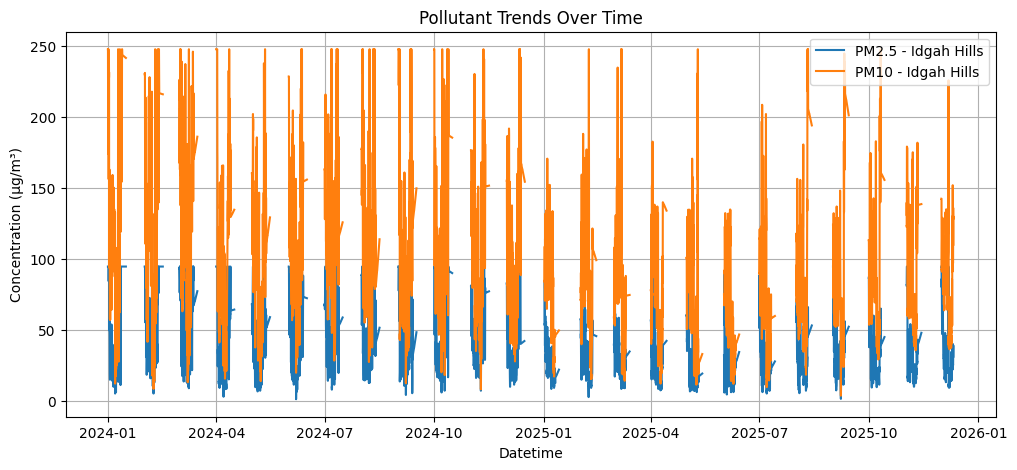

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(final_df.index, final_df['PM25_Idgah_Hills'], label='PM2.5 - Idgah Hills')
plt.plot(final_df.index, final_df['PM10_Idgah_Hills'], label='PM10 - Idgah Hills')
plt.title("Pollutant Trends Over Time")
plt.xlabel("Datetime")
plt.ylabel("Concentration (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()


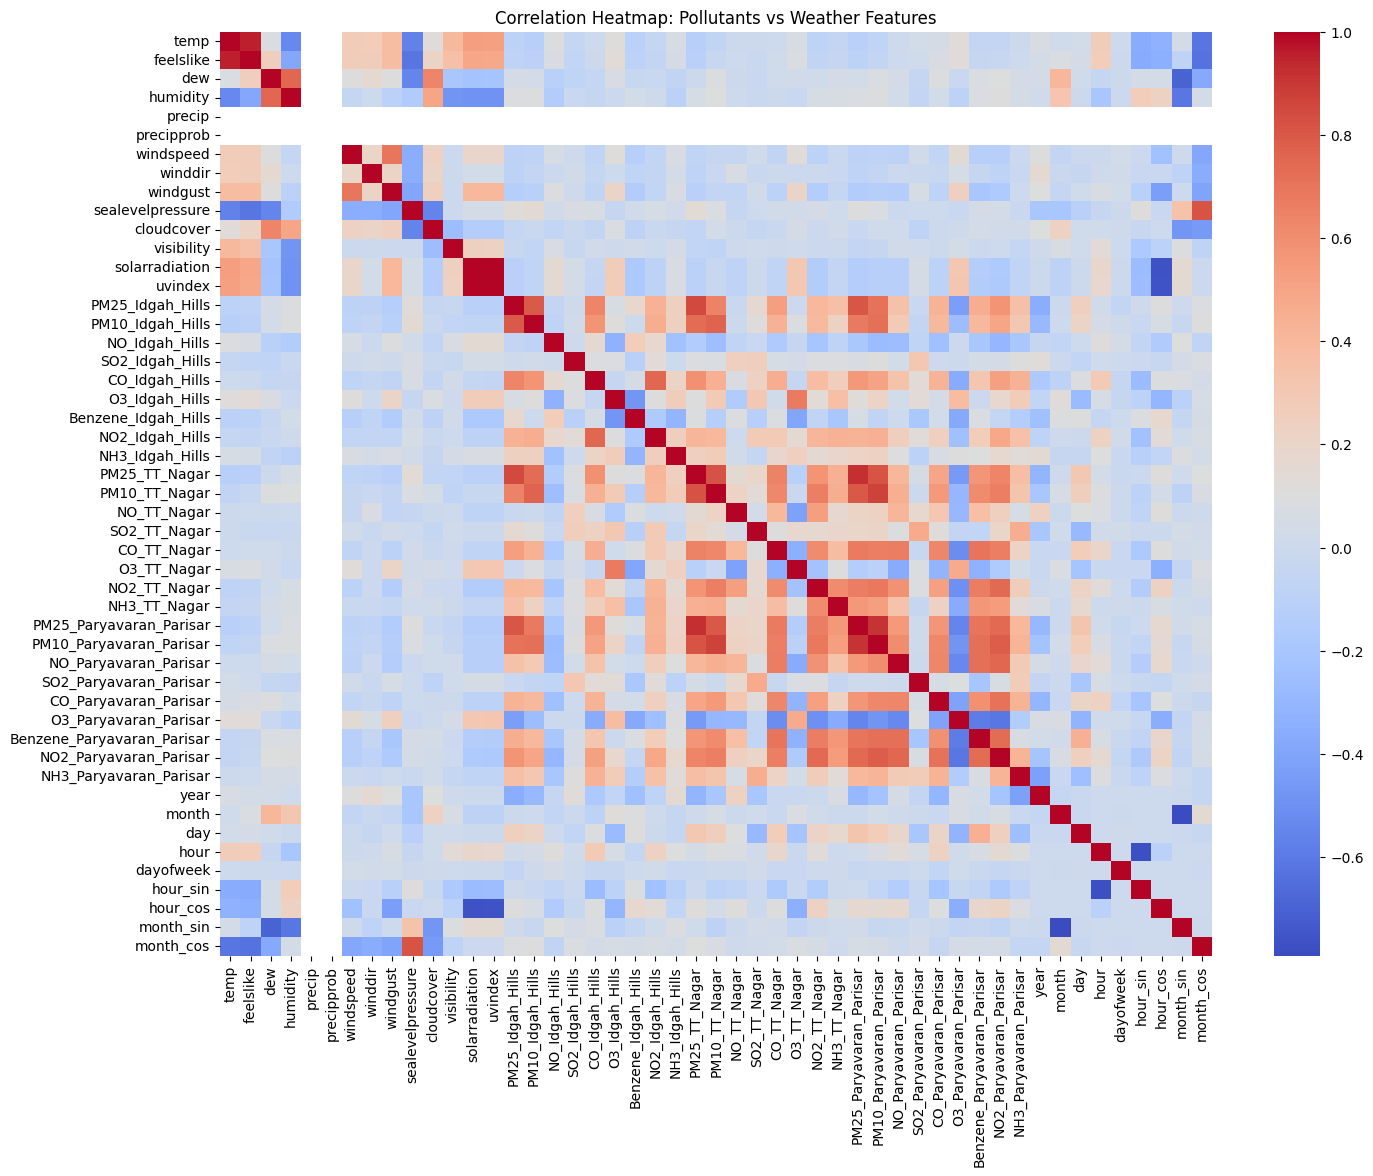

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(final_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap: Pollutants vs Weather Features")
plt.show()


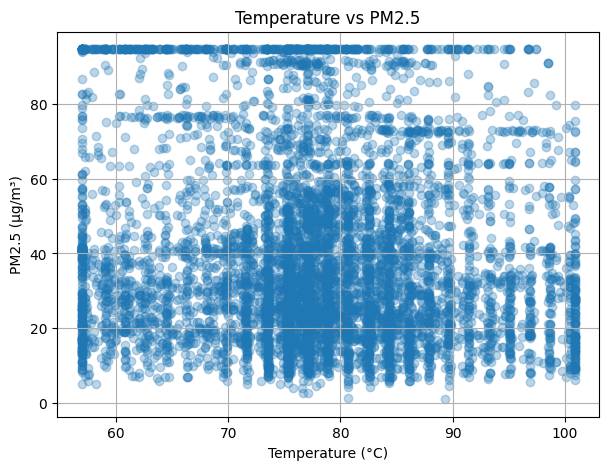

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(final_df['temp'], final_df['PM25_Idgah_Hills'], alpha=0.3)
plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.show()


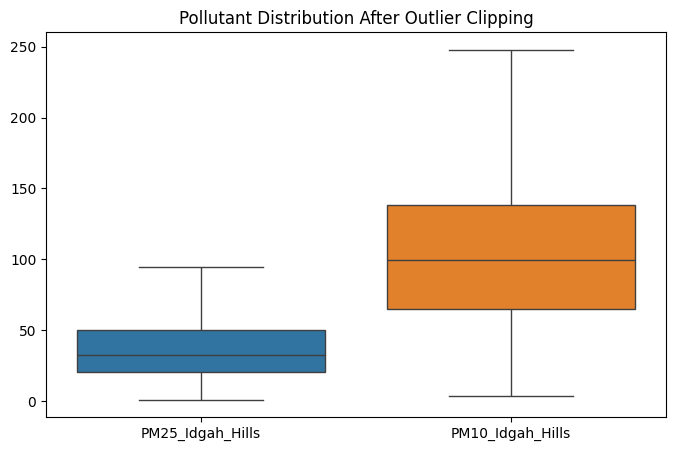

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=final_df[['PM25_Idgah_Hills', 'PM10_Idgah_Hills']])
plt.title("Pollutant Distribution After Outlier Clipping")
plt.show()
